<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_15_Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Assignment-15: CLUSTERING ANALYSIS

## Understanding and Implementing K-Means and DBSCAN Algorithms

### Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

Datasets : EastWestAirlines

### Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3.	Use multiple visualizations to understand the hidden patterns in the dataset

### Implementing Clustering Algorithms:
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

### Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

### Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

### Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


## Data Preprocessing:
### 1.Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
Procedure

Load dataset

Inspect structure (shape, data types, summary)

Handle missing values

Drop or impute (mean/median)

Detect and remove outliers

Use IQR method

Scale features

Use StandardScaler (important for clustering)

In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Read the "data" sheet
df = pd.read_excel("/content/EastWestAirlines.xlsx", sheet_name="data")

display(df.head())
df.shape

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


(3999, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


The dataset contains 3999 rows and 12 columns.

 Initial inspection shows that there are no missing values in the dataset, as the non-null count for all columns matches the total number of records.

  All the variables are of int64 data type, indicating that the dataset consists entirely of numerical integer features.
  
   Since clustering algorithms are distance-based, the numerical nature of the data makes it suitable for clustering after proper preprocessing such as outlier treatment and feature scaling.

In [ ]:
#Checking null values
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


Based on the df.describe() output, here are some additional observations and insights into the dataset's characteristics:

`ID#` appears to be a unique identifier with values ranging from 1 to 4021. Since it does not contribute meaningful information for grouping customers, it should be removed before clustering.

`Balance` shows a very wide range of values (0 to 1,704,838) with a large difference between the mean and median, indicating a highly right-skewed distribution and the presence of extreme outliers.

`Qual_miles` is heavily concentrated at 0, as reflected by the quartile values, while a few customers have very high qualifying miles. This suggests that only a small number of customers frequently accumulate qualifying miles.

`cc1_miles, cc2_miles, and cc3_miles` have small integer ranges and are concentrated around lower values, indicating that these variables likely represent ordinal or categorical membership levels rather than continuous numerical measurements.

`Bonus_miles` also exhibits strong positive skewness with very high maximum values compared to the quartiles, suggesting the presence of outliers.

`Bonus_trans, Flight_miles_12mo, and Flight_trans_12` display significant variability and skewness, meaning a few customers have substantially higher transaction counts and flight activity compared to the majority.

`Days_since_enroll` has a broad range from 2 to 8296, representing customer tenure in the airline program. The distribution appears relatively more balanced compared to other highly skewed variables.

`Award?` is a binary feature containing values 0 and 1, where the mean indicates that approximately 37% of customers have received an award.

Overall Observation

Most numerical variables exhibit strong right-skewness and contain potential outliers. Since clustering algorithms such as K-Means and DBSCAN are distance-based methods, proper preprocessing steps like outlier treatment and feature scaling are essential to improve clustering performance and obtain meaningful clusters.


### Drop Unnecessary Column

In [ ]:
df1 = df.drop('ID#', axis=1)
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


### Pairplot

Purpose:

understand distributions

identify skewness

inspect relationships

observe possible grouping tendencies

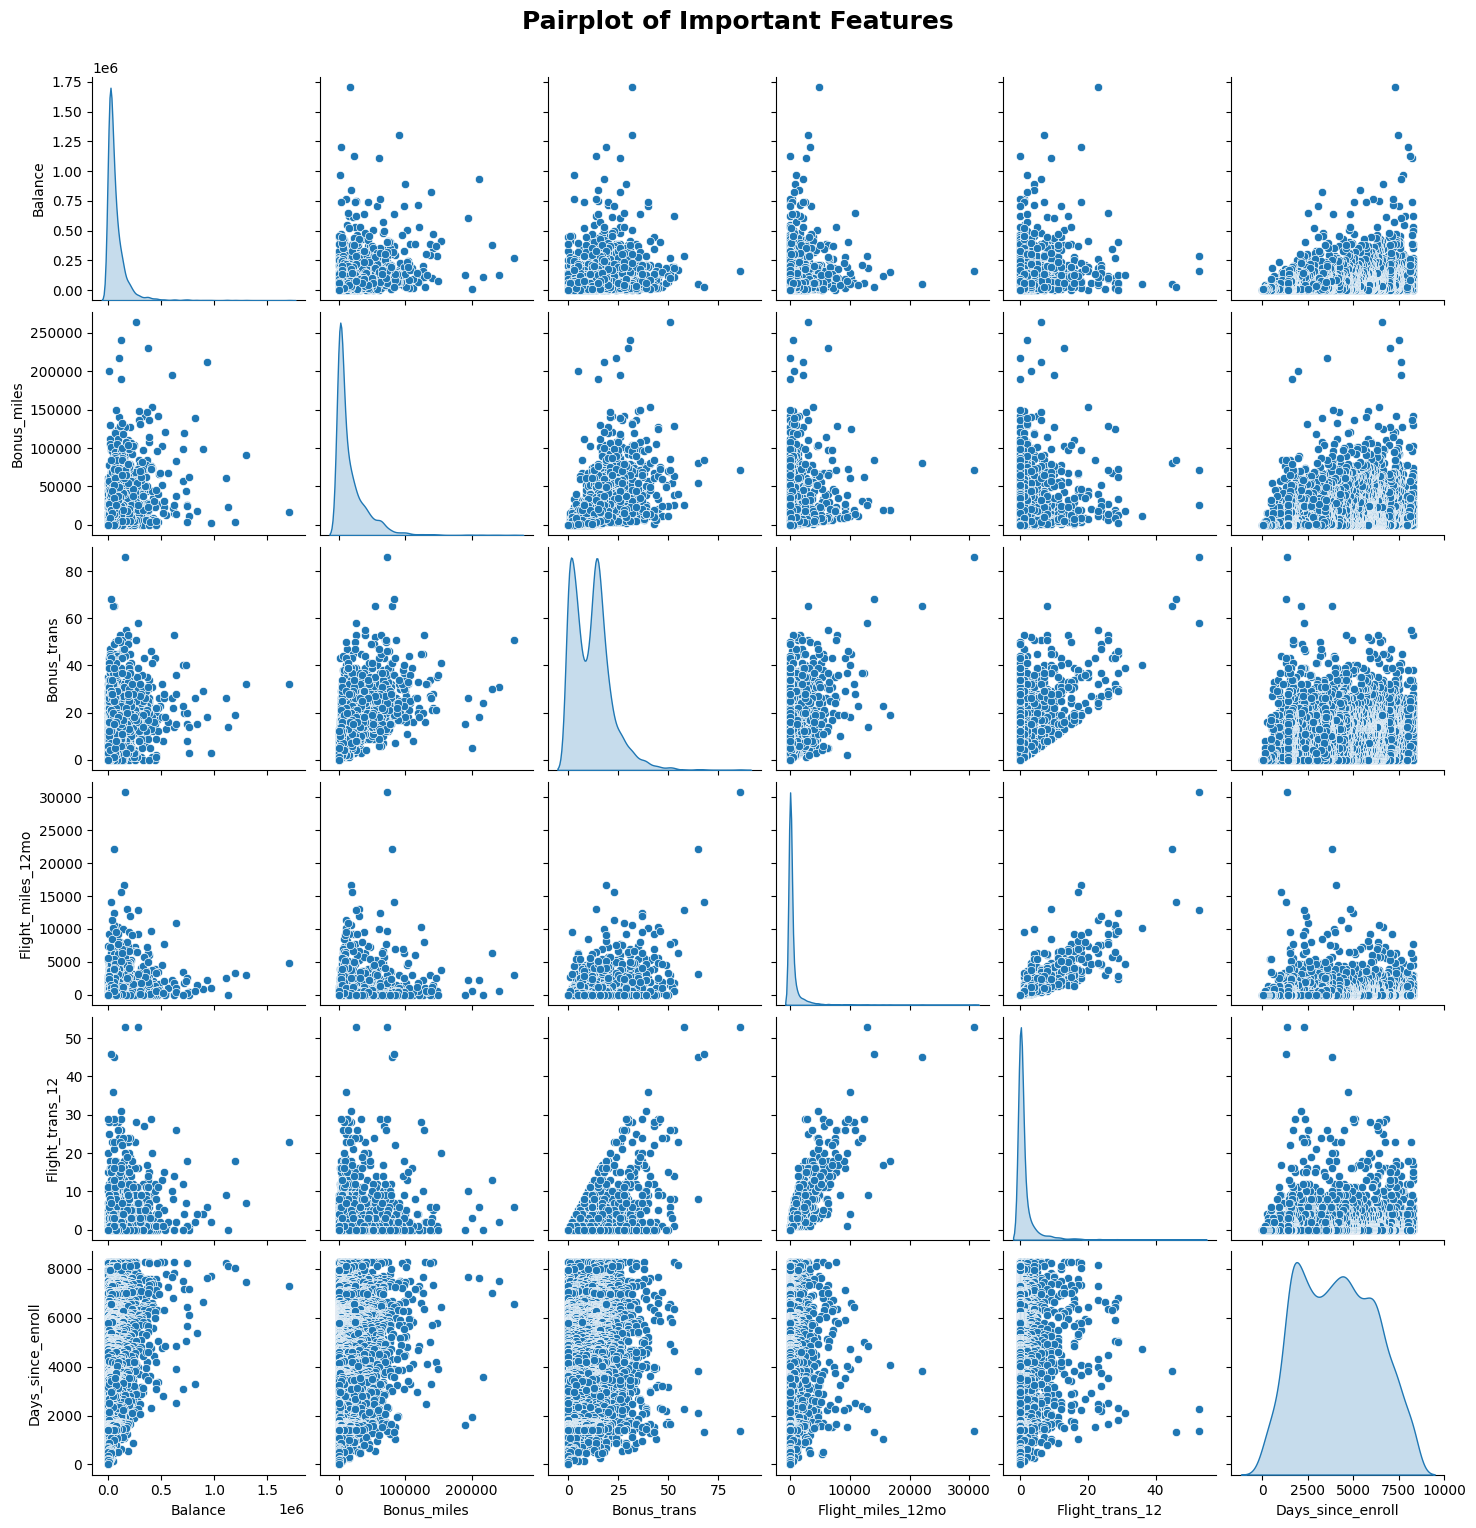

In [ ]:
# Select important continuous variables
pairplot_cols = ['Balance',
                 'Bonus_miles',
                 'Bonus_trans',
                 'Flight_miles_12mo',
                 'Flight_trans_12',
                 'Days_since_enroll']

# Create pairplot
sns.pairplot(df1[pairplot_cols],
             diag_kind='kde')

# Main title
plt.suptitle('Pairplot of Important Features',
             fontsize=18,
             fontweight='bold',
             y=1.02)

plt.show()

The pairplot reinforces the need for robust clustering algorithms that can handle skewed data, varying densities, and potentially non-spherical cluster shapes.This suggests that robust clustering methods may be beneficial as it is designed to find density-connected clusters and can naturally isolate outliers that might otherwise distort K-Means results. K-Means, if used, would heavily rely on the effectiveness of the log transformation and standardization to minimize the impact of skewness and scale differences.



### Heatmap

Purpose:

analyze feature relationships

understand customer behavior patterns

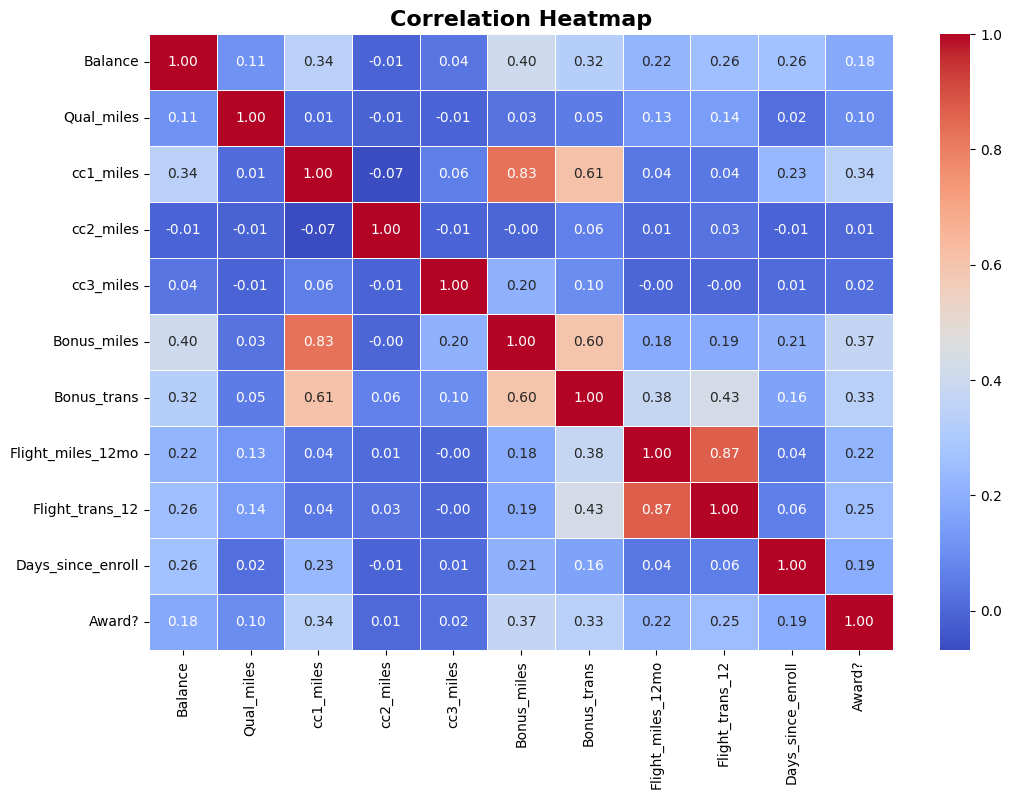

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df1.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap',
          fontsize=16,
          fontweight='bold')

plt.show()

The correlation heatmap shows the relationships between customer activity variables in the dataset. Strong positive correlations are observed between Bonus_miles and Bonus_trans, as well as Flight_miles_12mo and Flight_trans_12, indicating that customers with higher transaction activity tend to accumulate more miles.

Most other variables show weak to moderate correlations, suggesting that the dataset contains diverse and independent customer behavior patterns, which is beneficial for clustering analysis.

The heatmap also helps in understanding how variables may influence distance-based clustering algorithms such as K-Means and density-based clustering methods like DBSCAN, thereby supporting better interpretation of the clusters formed.

### Detect Outliers Using Boxplots

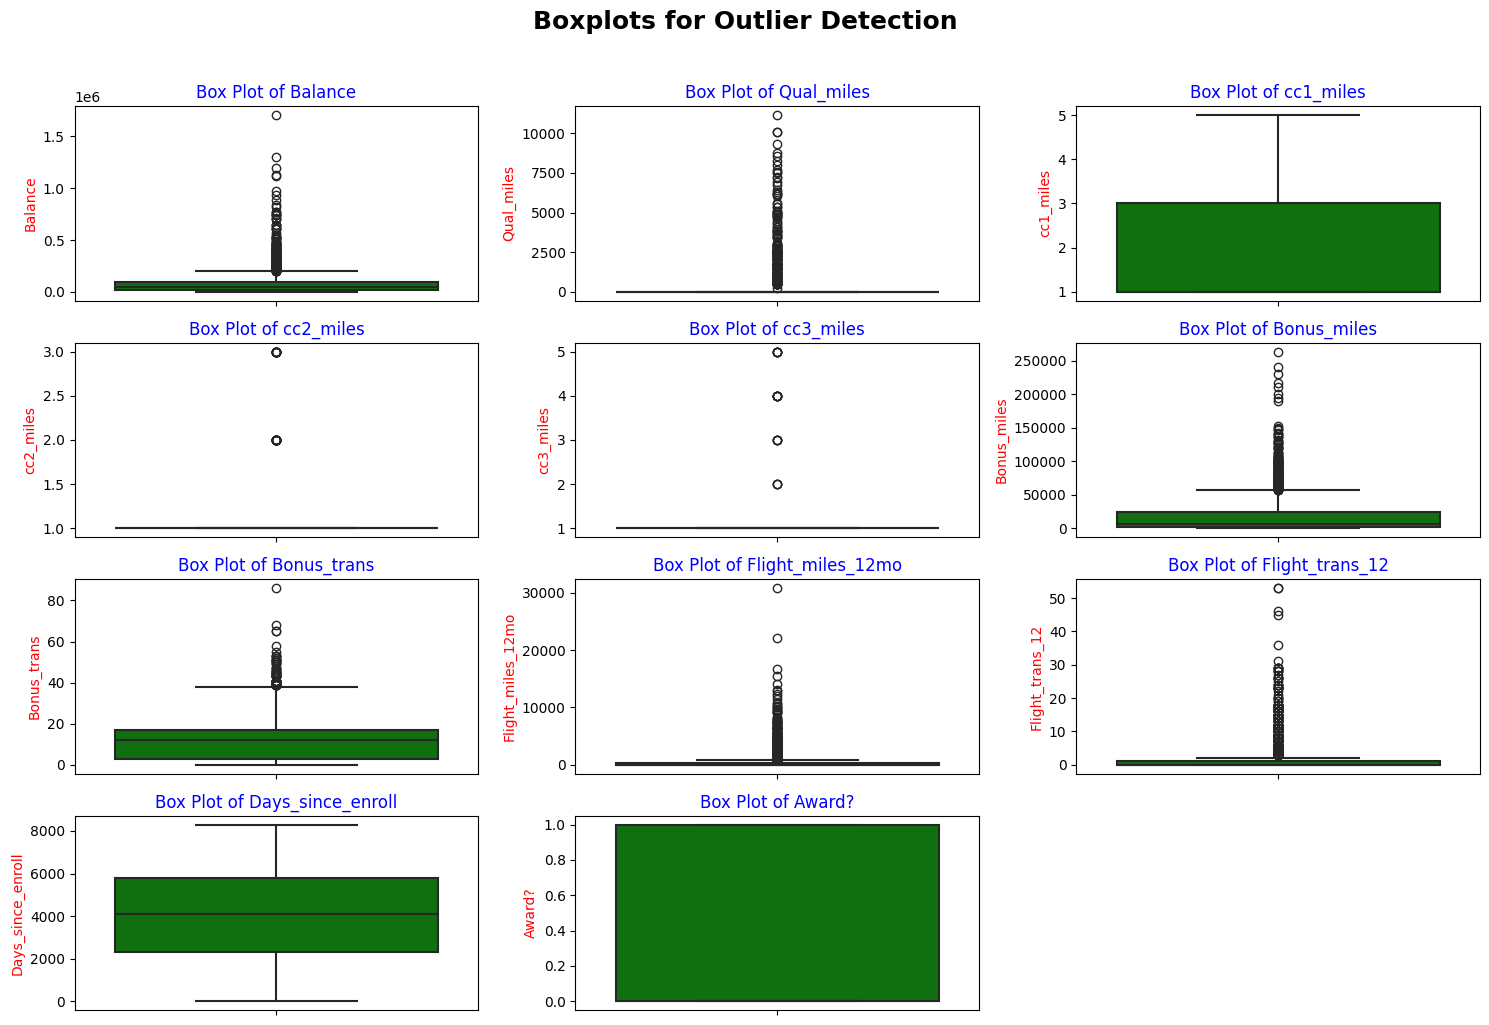

In [ ]:
plt.figure(figsize=(15,10))
for i,col in enumerate (df1.columns):
  plt.subplot(4,3,i+1)
  sns.boxplot(df1[col],color='green',linewidth=1.5)
  plt.title(f"Box Plot of {col}",color='blue')
  plt.ylabel(col,color='red')
plt.suptitle(
    'Boxplots for Outlier Detection',
    fontsize=18,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()


The box plots indicate the presence of strong positive skewness and several extreme values in variables such as Balance, Qual_miles, Bonus_miles, Flight_miles_12mo, and Flight_trans_12. This shows that while most customers have moderate activity levels, a smaller group of customers exhibit exceptionally high balances, mileage accumulation, and flight activity.

Variables like cc1_miles, cc2_miles, cc3_miles, and Award? appear to contain discrete values, indicating categorical or ordinal characteristics.

Since DBSCAN inherently identifies low-density observations as noise points, explicit outlier removal is avoided. Therefore, logarithmic transformation and feature scaling are applied in the next step to reduce skewness and standardize feature magnitudes before clustering analysis.

### Note on Outlier Handling

Although outliers were detected using boxplots, explicit outlier removal was not performed because:

1. DBSCAN naturally identifies outliers as noise points.

2. Log transformation reduces the impact of extreme values.

3. Standardization minimizes feature scale dominance.

Therefore, all observations were retained to preserve important customer behavior patterns while still reducing the influence of skewed distributions.

### Feature Scaling Consideration

Although variables such as cc1_miles, cc2_miles, cc3_miles, and Award? exhibit categorical or ordinal characteristics, they are retained as numerical features and included in the scaling process. This is because clustering algorithms such as K-Means and DBSCAN rely on distance calculations, and scaling ensures that all features contribute proportionately during cluster formation.

### Feature Transformation and Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Copy dataset
df_transformed = df1.copy()

# Apply log transformation only to skewed columns
skewed_cols = ['Balance',
               'Qual_miles',
               'Bonus_miles',
               'Bonus_trans',
               'Flight_miles_12mo',
               'Flight_trans_12']

for col in skewed_cols:
    df_transformed[col] = np.log1p(df_transformed[col])

# Apply StandardScaler to all columns
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_transformed)

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data,
                         columns=df_transformed.columns)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.240588,-0.243383,-0.769578,-0.098242,-0.062767,-0.829165,-1.350586,-0.669104,-0.576530,1.395454,-0.766919
1,-0.538514,-0.243383,-0.769578,-0.098242,-0.062767,-0.764962,-0.967138,-0.669104,-0.576530,1.379957,-0.766919
2,0.061081,-0.243383,-0.769578,-0.098242,-0.062767,0.134622,-0.484051,-0.669104,-0.576530,1.411920,-0.766919
3,-0.745589,-0.243383,-0.769578,-0.098242,-0.062767,-0.508343,-1.350586,-0.669104,-0.576530,1.372208,-0.766919
4,0.735382,-0.243383,1.409471,-0.098242,-0.062767,0.851822,1.110774,1.760457,1.575216,1.363975,1.303918


## Implementing Clustering Algorithms
### K-Means Clustering
### Finding Optimal Number of Clusters using Elbow Method
Purpose

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering by analyzing the Within-Cluster Sum of Squares (WCSS).

As the number of clusters increases, WCSS decreases. The optimal cluster value is identified at the “elbow point,” where the rate of decrease sharply changes.

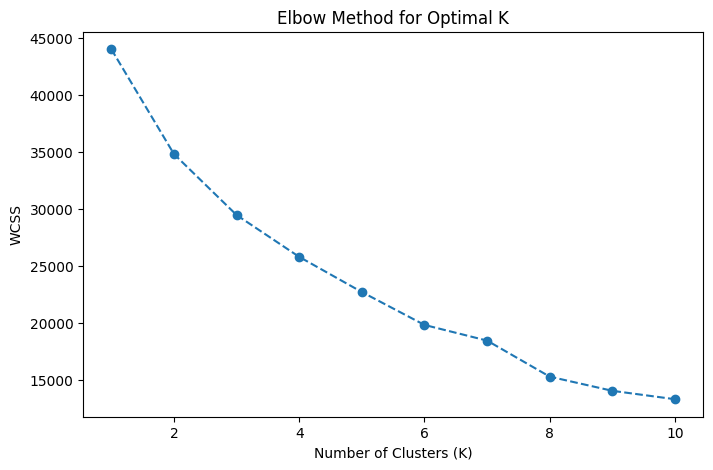

In [ ]:
from sklearn.cluster import KMeans

# Empty list to store WCSS
wcss = []

# Calculate WCSS for different K values
for i in range(1,11):

    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10
                    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o',
         linestyle='--')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.title('Elbow Method for Optimal K')

plt.show()

Analyzing the elbow plot, we look for the point where the decrease in WCSS (Within-Cluster Sum of Squares) starts to level off, forming an 'elbow' shape. This point indicates that adding more clusters beyond it provides diminishing returns in terms of reducing within-cluster variance.

Although the elbow is not very sharp, choosing K = 4 is reasonable because it represents the point after which the reduction in WCSS becomes more gradual, indicating diminishing improvement from adding extra clusters. Additionally, K = 4 provides a good balance between model simplicity and cluster separation.

In [ ]:
# Build K-Means model
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=10
                )

# Fit and predict clusters
kmeans_labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to dataset
df_kmeans = df1.copy()

df_kmeans['Cluster'] = kmeans_labels

df_kmeans.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2
1,19244,0,1,1,1,215,2,0,0,6968,0,2
2,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,14776,0,1,1,1,500,1,0,0,6952,0,2
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0


In [ ]:
kmeans_labels

array([2, 2, 1, ..., 1, 2, 2], dtype=int32)

In [ ]:
## Cluster Distribution
df_kmeans['Cluster'].value_counts()

,count
Cluster,
1,1735
0,1167
2,1082
3,15


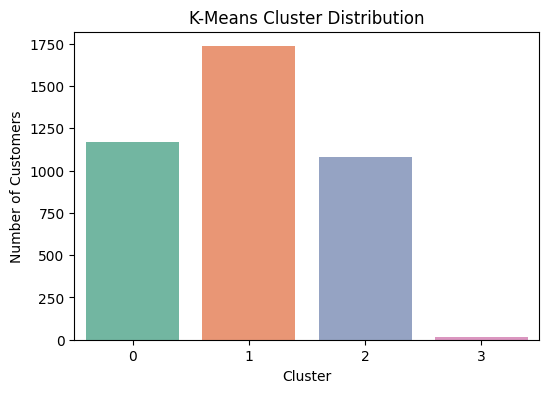

In [ ]:
# Cluster distribution plot

plt.figure(figsize=(6,4))

sns.countplot(
    x='Cluster',
    data=df_kmeans,
    palette='Set2'
)

plt.title('K-Means Cluster Distribution')

plt.xlabel('Cluster')

plt.ylabel('Number of Customers')

plt.show()

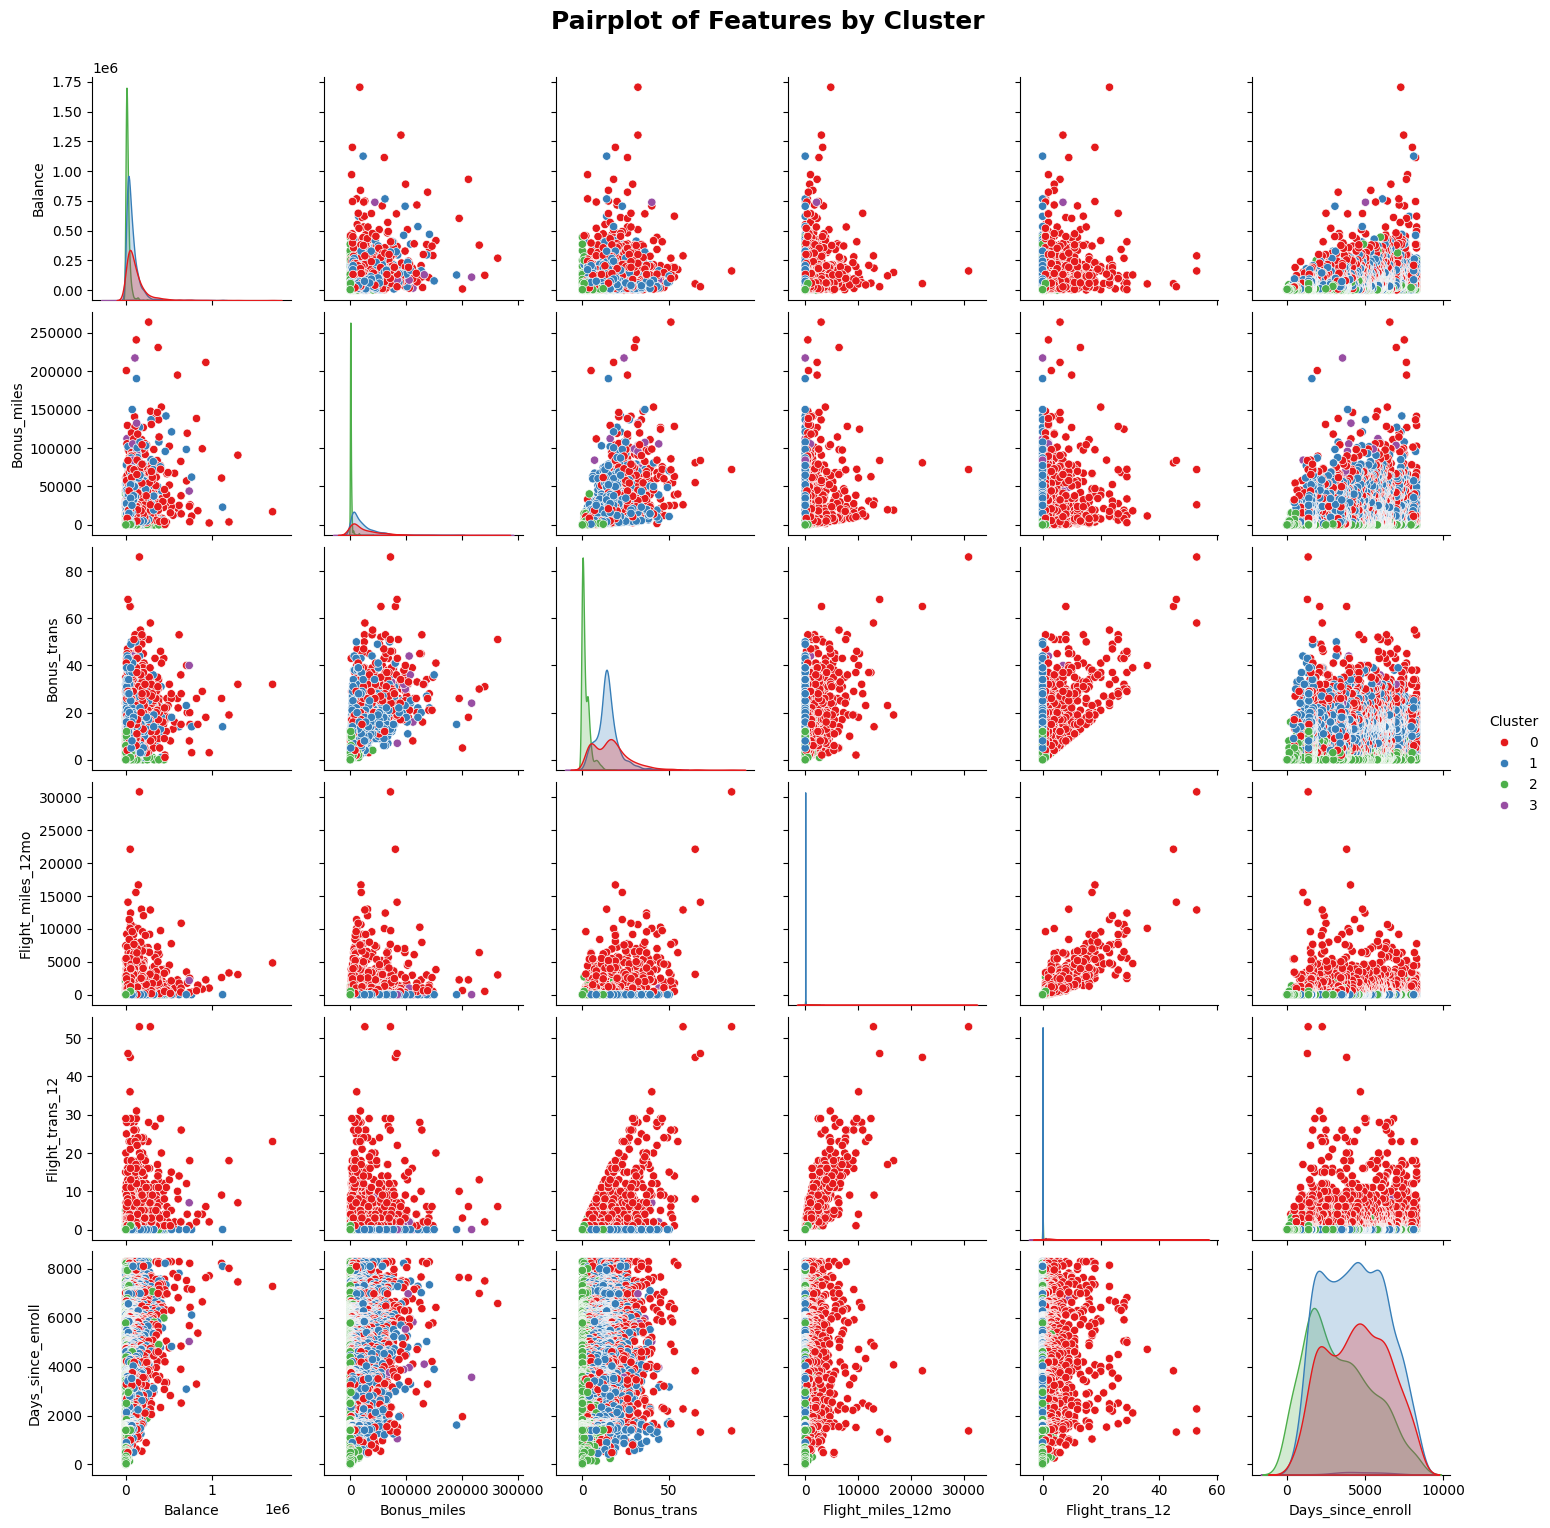

In [ ]:
#Pairplot with hue = 'Cluster'
# Select important continuous variables
# Add cluster labels to original dataframe is already done - see "df_kmeans" above

# Selected columns for pairplot
pairplot_cols = ['Balance',
                 'Bonus_miles',
                 'Bonus_trans',
                 'Flight_miles_12mo',
                 'Flight_trans_12',
                 'Days_since_enroll',
                 'Cluster']

# Create pairplot
sns.pairplot(df_kmeans[pairplot_cols],
             hue='Cluster',
             diag_kind='kde',
             palette='Set1')

# Main title
plt.suptitle('Pairplot of Features by Cluster',
             fontsize=18,
             fontweight='bold',
             y=1.02)

plt.show()

### Evaluate K-Means using Silhouette Score
Purpose

The silhouette score measures how well-separated and compact the clusters are.

Score closer to +1 → better clustering

Score near 0 → overlapping clusters

Negative score → poor clustering

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
kmeans_silhouette = silhouette_score(scaled_df,
                                     kmeans_labels)

print("Silhouette Score for K-Means :",
      round(kmeans_silhouette,3))

Silhouette Score for K-Means : 0.239


A score of 0.239 is relatively low. This suggests that while there is some level of separation among the clusters, they are not particularly compact or well-distinguished. It indicates that:

Clusters are somewhat overlapping

Less distinct separation

Potential for improvement



### Cluster Summary Statistics

This helps interpret the characteristics of each cluster.

In [ ]:
# Cluster-wise mean analysis
kmeans_cluster_summary = df_kmeans.groupby('Cluster').mean()

kmeans_cluster_summary

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,
0,118099.615253,320.872322,2.378749,1.018852,1.000000,25966.617823,16.383890,1542.940874,4.572408,4473.519280,0.613539
1,74700.774640,81.501441,2.493372,1.020749,1.001729,20697.073199,14.350432,0.432277,0.008069,4351.087608,0.380403
2,22950.732902,54.777264,1.000000,1.000000,1.000000,869.553604,1.808688,28.466728,0.109982,3355.986137,0.089649
3,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333


In [ ]:
# Mean and Median cluster profile

cluster_profile = df_kmeans.groupby('Cluster').agg(['mean', 'median'])

cluster_profile

Balance            Qual_miles        cc1_miles         \
                  mean    median        mean median      mean median   
Cluster                                                                
0        118099.615253   75039.0  320.872322    0.0  2.378749    2.0   
1         74700.774640   53210.0   81.501441    0.0  2.493372    3.0   
2         22950.732902   15259.0   54.777264    0.0  1.000000    1.0   
3        138061.400000  108081.0   78.800000    0.0  3.466667    4.0   

        cc2_miles        cc3_miles         ... Bonus_trans         \
             mean median      mean median  ...        mean median   
Cluster                                    ...                      
0        1.018852    1.0  1.000000    1.0  ...   16.383890   15.0   
1        1.020749    1.0  1.001729    1.0  ...   14.350432   14.0   
2        1.000000    1.0  1.000000    1.0  ...    1.808688    1.0   
3        1.000000    1.0  4.066667    4.0  ...   28.066667   30.0   

        Flight_miles_12mo        Flight_trans_12        Days_since_enroll  \
                     mean median            mean median              mean   
Cluster                                                                     
0             1542.940874  736.0        4.572408    2.0       4473.519280   
1                0.432277    0.0        0.008069    0.0       4351.087608   
2               28.466728    0.0        0.109982    0.0       3355.986137   
3              506.666667    0.0        1.600000    0.0       4613.866667   

                   Award?         
         median      mean median  
Cluster                           
0        4497.0  0.613539    1.0  
1        4373.0  0.380403    0.0  
2        3042.0  0.089649    0.0  
3        4103.0  0.533333    1.0  

[4 rows x 22 columns]

### Cluster Interpretation based on Group-wise Means

The K-Means clustering algorithm segmented customers into four distinct groups based on their average behavioral characteristics.

Cluster 0 contains customers with high balances, high flight activity, large bonus miles, and a high proportion of award holders. These customers represent loyal and high-value frequent travelers.
Cluster 1 shows very high credit card mileage and bonus miles with 100% award membership but relatively low flight activity. This cluster represents customers who mainly earn rewards through credit card usage rather than frequent flying.
Cluster 2 consists of customers with moderate balances and transaction activity but no award membership. These customers represent moderately engaged users without premium benefits.
Cluster 3 has the lowest averages across most variables, including balances, transactions, and flight activity, along with very low award participation. This cluster likely represents low-activity or newly enrolled customers.

The cluster-wise mean analysis helps convert the clustering output into meaningful customer segments, enabling better understanding of customer behavior patterns and supporting business-oriented decision-making.

### K-Means Visualization using PCA

Since the dataset has many dimensions, PCA helps visualize clusters in 2D.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

# Explained variance by PCA components

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")

print(round(pca.explained_variance_ratio_.sum(), 3))


Explained Variance Ratio:
[0.31785    0.15123336]

Total Variance Explained:
0.469


The first principal component explains approximately 31.8% of the total variance in the dataset, while the second principal component explains about 15.1%. Together, the first two components account for nearly 46.9% of the total variance, indicating that they capture a moderate amount of the information present in the original data. If n_components = 3, then it is 56.4%.

This suggests that the 2D PCA projection provides a simplified representation of the dataset, though some information is still lost since more than half of the variance remains unexplained.

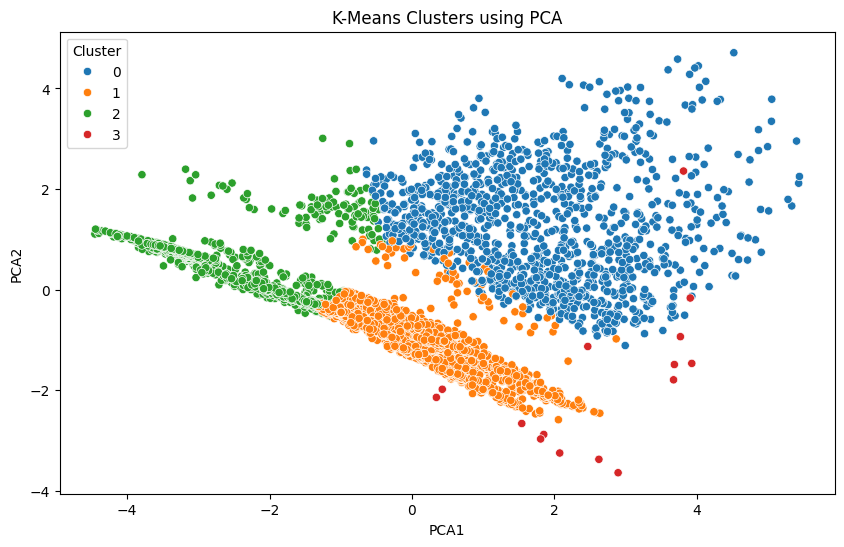

In [ ]:
# Create PCA dataframe
pca_df = pd.DataFrame(pca_components,
                      columns=['PCA1', 'PCA2'])

# Add cluster labels
pca_df['Cluster'] = kmeans_labels

# Plot clusters
plt.figure(figsize=(10,6))

sns.scatterplot(data=pca_df,
                x='PCA1',
                y='PCA2',
                hue='Cluster',
                palette='tab10') # Changed 'set1' to 'tab10'

plt.title('K-Means Clusters using PCA')

plt.show()

### PCA Interpretation

The PCA visualization provides a two-dimensional representation of the clusters generated by the K-Means algorithm. Although distinct customer groups are visible, some overlap exists between clusters, indicating that customer behaviors are not completely separable. This observation is consistent with the relatively low silhouette score(0.239) obtained earlier, suggesting moderate cluster compactness and separation.

The overlap in clusters indicates that certain customers share similar behavioral characteristics across groups. Since K-Means assumes spherical and clearly separated clusters, the PCA results suggest that alternative clustering approaches such as DBSCAN may further improve cluster identification by handling varying densities and outliers more effectively.

# DBSCAN Clustering
Why DBSCAN?

DBSCAN is useful because:

It identifies clusters based on density.

It can detect outliers automatically.

It works well for irregular cluster shapes.

It is less sensitive to outliers compared to K-Means.

### determine an appropriate value for the eps (epsilon) parameter in DBSCAN clustering using the k-distance graph (elbow method)

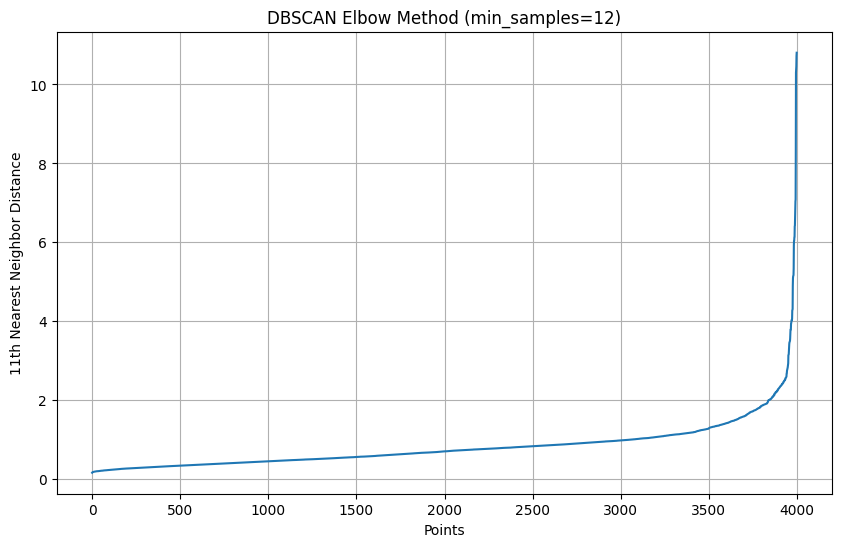

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Find optimal eps

# Number of features = 11
# Recommended min_samples = features + 1 = 12

neighbors = NearestNeighbors(n_neighbors=12)

neighbors_fit = neighbors.fit(scaled_df)

distances, indices = neighbors_fit.kneighbors(scaled_df)

# Distance to 12th nearest neighbor

distances = np.sort(distances[:, 11])

# Plot elbow graph
plt.figure(figsize=(10,6))
plt.plot(distances)

plt.xlabel("Points")

plt.ylabel("11th Nearest Neighbor Distance")

plt.title("DBSCAN Elbow Method (min_samples=12)")
plt.grid(True)
plt.show()

### Interpretation of the Elbow Graph

From the k-distance (elbow) graph, the curve shows a sharp increase in distance values around 0.9. This point represents the transition from dense regions to sparse regions in the dataset and is therefore selected as the optimal value for eps.

### DBSCAN clustering algorithm to the scaled dataset in order to identify clusters based on data density.

In [ ]:
# DBSCAN model
dbscan = DBSCAN(
    eps=0.9,
    min_samples=12 # number of features + 1
)

dbscan.fit(scaled_df)

# Cluster labels
labels = dbscan.labels_

print(labels)

[0 0 0 ... 3 6 2]


### Interpretation of DBSCAN Cluster Labels

The labels array represents the cluster assignment generated by the DBSCAN model for each data point in the dataset.

The values in the labels array can be interpreted as follows:

-1: Indicates noise points or outliers. These points do not belong to any cluster because they do not have a sufficient number of neighboring points within the specified eps radius to form a dense region.
0, 1, 2, 3, ...: Represent the different clusters identified by DBSCAN. Each unique positive integer corresponds to a separate cluster.

Thus, DBSCAN not only groups similar data points into clusters but also effectively identifies anomalous or isolated observations as noise points.

To further analyze the clustering outcome, we can count:

the number of points in each cluster, and
the total number of noise points (-1 labels),

which provides a clearer understanding of the cluster distribution and the presence of outliers in the dataset.

In [ ]:
from collections import Counter

# Count unique values in labels array
label_counts = Counter(labels)

# Print labels in sorted order
for label in sorted(label_counts):
    print(f"Label {label}: {label_counts[label]}")

Label -1: 719
Label 0: 1462
Label 1: 231
Label 2: 421
Label 3: 618
Label 4: 138
Label 5: 22
Label 6: 388


### Interpretation of DBSCAN Output

Based on the output generated by the DBSCAN model, the dataset has been segmented into 7 distinct clusters (labeled 0 to 6), along with a considerable number of noise points identified as outliers.

Noise Points (Label -1): 719 samples

Approximately 18% of the total observations (719 out of 3999 samples) were classified as noise points. These points do not belong to any dense region and therefore could not be assigned to a cluster. One of the major advantages of DBSCAN is its ability to explicitly detect such outliers instead of forcing them into clusters.

Cluster 0: 1462 samples

Cluster 0 is the largest cluster in the dataset, containing a significant proportion of the observations. This cluster likely represents the dominant customer segment or the most frequently occurring behavioral pattern within the dataset.

Cluster 3: 618 samples

This is the second largest cluster identified by DBSCAN, indicating another major and meaningful customer segment.

Cluster 2: 421 samples

Cluster 2 represents a moderately sized group of observations with similar characteristics.

Cluster 6: 388 samples

Another moderately sized cluster, suggesting a distinct but less dominant behavioral pattern compared to the larger clusters.

Cluster 1: 231 samples

This cluster contains a smaller but clearly distinguishable group of customers or observations.

Cluster 4: 138 samples

A relatively small cluster, potentially representing a niche customer segment with more specialized characteristics.

Cluster 5: 22 samples

This is the smallest cluster identified by DBSCAN. Such a small cluster may indicate rare or infrequent behavioral patterns within the dataset.

Overall,

The DBSCAN model has effectively identified both large and small clusters within the data while simultaneously detecting outliers. Unlike clustering techniques such as K-Means, DBSCAN does not force every data point into a cluster, making it particularly useful for datasets containing noise or irregular cluster shapes.

The presence of multiple cluster sizes suggests that the dataset contains diverse customer groups or behavioral patterns. Additionally, the large number of noise points may indicate anomalous behaviors, uncommon customer profiles, or potential data irregularities that could be investigated further for deeper business insights.


In [ ]:
# Add DBSCAN labels to original dataframe
df_dbscan = df1.copy()
df_dbscan['Cluster'] = labels

display(df_dbscan.head())

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [ ]:
df_cluster_3 = df_dbscan[df_dbscan['Cluster'] == 3]

display(df_cluster_3.head())
df_cluster_3.shape

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
11,96522,0,5,1,1,61105,19,0,0,6924,1,3
15,28495,0,4,1,1,49442,15,0,0,6912,1,3
16,51890,0,4,1,1,48963,16,0,0,6910,1,3
17,13958,0,1,1,1,4291,5,0,0,6905,1,3
18,91473,0,3,1,1,27408,17,0,0,6903,1,3


(618, 12)

## Visualization of the clusters using PCA

Since the dataset contains 11 features, direct visualization of the clusters in the original feature space is not practical. Therefore, Principal Component Analysis (PCA) was previously applied to reduce the dimensionality of the dataset while preserving the maximum possible variance in the data.

The transformed dataframe pca_df contains two principal components:

PCA1

PCA2

These two components represent the directions that explain the largest variation in the dataset and provide the best two-dimensional representation of the original data.

To visualize the clusters identified by the DBSCAN model, the cluster labels are mapped to the observations in pca_df. A scatter plot is then generated using:

PCA1 on the x-axis
PCA2 on the y-axis

Different colors represent different clusters, while noise points identified by DBSCAN (label = -1) appear separately. This visualization helps in understanding the separation, density, and distribution of the clusters as well as the presence of outliers in the dataset.


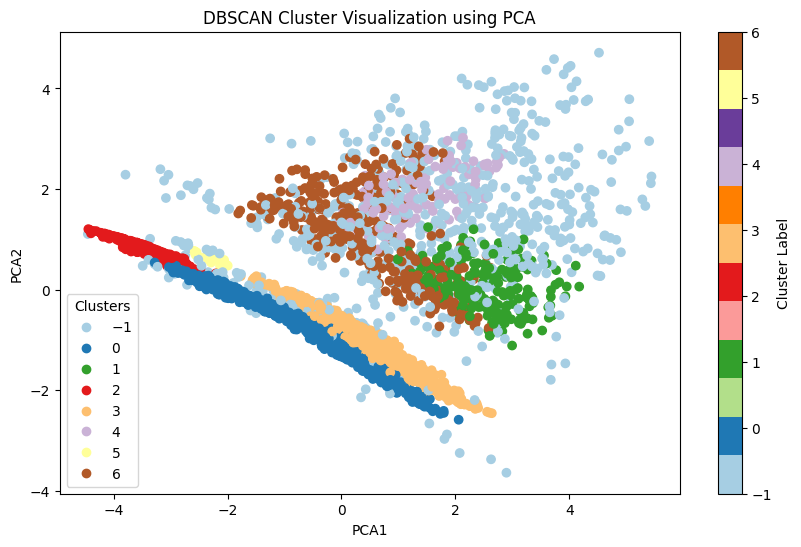

In [ ]:
# Add cluster labels to PCA dataframe
pca_df['Cluster'] = labels

# Plot clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster'],
    #cmap='tab10'
    #cmap='Set1'
    #cmap='tab20'
    cmap='Paired'
    #cmap='Dark2'
    )

plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.title('DBSCAN Cluster Visualization using PCA')

plt.colorbar(scatter, label='Cluster Label')

plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

In above visual Light blue (-1) are outliers.



### DBSCAN Cluster Visualization (Excluding Noise Points)

This visualization removes the noise points (labeled -1) to provide a clearer view of the identified clusters.

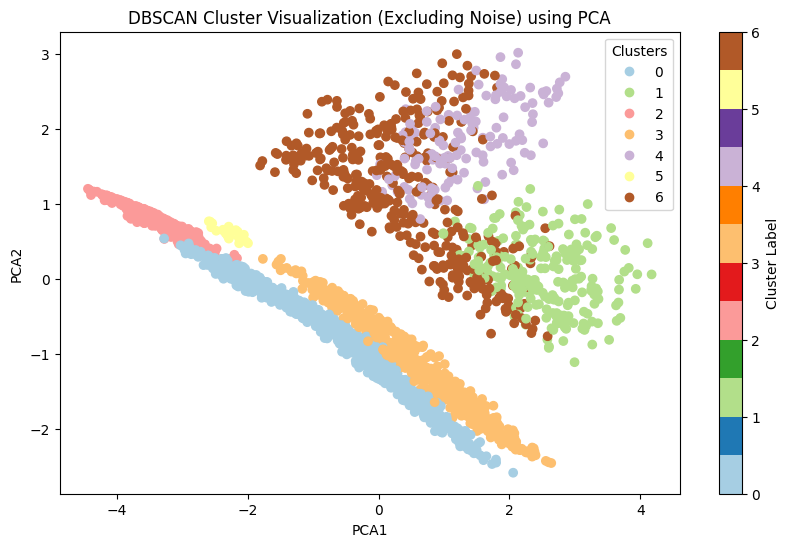

In [ ]:


# Ensure pca_df is up-to-date with current labels
pca_df_filtered = pca_df.copy()
pca_df_filtered['Cluster'] = labels

# Filter out noise points (label -1)
clustered_pca_df = pca_df_filtered[pca_df_filtered['Cluster'] != -1]

# Plot clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    clustered_pca_df['PCA1'],
    clustered_pca_df['PCA2'],
    c=clustered_pca_df['Cluster'],
    #cmap='Dark2'
    cmap='Paired'
    )

plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.title('DBSCAN Cluster Visualization (Excluding Noise) using PCA')

plt.colorbar(scatter, label='Cluster Label')

plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

### The seven clusters are now clearly visible

### Silhouette Score for DBSCAN

In [ ]:
# Remove noise points (-1) before silhouette calculation
dbscan_mask = labels != -1

# Calculate silhouette score only if more than 1 cluster exists
if len(set(labels[dbscan_mask])) > 1:

    dbscan_silhouette = silhouette_score(
        scaled_df[dbscan_mask],
        labels[dbscan_mask]
    )

    print("Silhouette Score for DBSCAN:",
          round(dbscan_silhouette, 3))

else:
    print("Silhouette score cannot be calculated.")

Silhouette Score for DBSCAN: 0.265


In [ ]:
labels.shape

(3999,)

#Silhouette_score interpretation
The silhouette score for DBSCAN is 0.265, which is slightly higher than the K-Means silhouette score of 0.239.

This indicates that DBSCAN produced clusters that are relatively better separated and more compact compared to K-Means. Although both scores are moderate, the higher DBSCAN score suggests that DBSCAN was more effective in capturing the underlying structure of the dataset.

The improved performance of DBSCAN can be attributed to its ability to identify clusters based on density, handle irregular cluster shapes, and automatically detect noise points or outliers instead of forcing all observations into clusters.

In contrast, K-Means assumes spherical and evenly sized clusters, which may not fully suit this dataset because several variables exhibit skewness, varying densities, and extreme values.

Therefore, based on the silhouette score comparison and clustering behavior, DBSCAN appears to be more suitable for the EastWestAirlines dataset.

### DBSCAN Cluster Summary Statistics

In [ ]:
# Add DBSCAN labels to original dataframe
df_dbscan = df1.copy()

df_dbscan['Cluster'] = labels

# Remove noise points for analysis
dbscan_clusters = df_dbscan[df_dbscan['Cluster'] != -1]

# Cluster-wise summary
dbscan_cluster_summary = dbscan_clusters.groupby('Cluster').mean()

dbscan_cluster_summary

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,
0,59143.648427,0.0,1.879617,1.0,1.0,12009.433653,10.855677,0.000000,0.000000,3870.387141,0.0
1,103321.194805,0.0,3.956710,1.0,1.0,45927.701299,20.173160,651.367965,1.787879,4949.874459,1.0
2,23544.092637,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,3387.097387,0.0
3,67480.365696,0.0,2.904531,1.0,1.0,26973.624595,14.514563,0.000000,0.000000,4536.064725,1.0
4,96945.166667,0.0,1.014493,1.0,1.0,7498.804348,7.717391,1575.326087,4.471014,4226.384058,1.0
5,28058.909091,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,5752.545455,1.0
6,74240.615979,0.0,1.708763,1.0,1.0,10768.391753,9.891753,844.793814,2.378866,3731.231959,0.0


### Interpretation of DBSCAN Cluster Summary

The DBSCAN algorithm segmented the customers into 7 distinct clusters (0–6) while also identifying a considerable number of noise points (labeled -1), which were excluded from the cluster summary analysis. The cluster-wise mean values provide valuable insights into the behavioral characteristics of each customer group.

Cluster 0 represents the largest customer group with moderate account balances, average bonus miles and transactions, and little to no flight activity. Most customers in this cluster do not possess award status, indicating moderately engaged but non-premium customers.

Cluster 1 consists of customers with comparatively higher balances, significantly larger bonus miles, and higher transaction activity. A large proportion of customers in this cluster hold award status and also exhibit some flight activity. These customers can be considered high-value or reward-oriented users.

Cluster 2 represents low-activity customers characterized by very low balances, minimal bonus accumulation, and almost no flight activity. These customers may correspond to newly enrolled or inactive users.

Cluster 3 contains customers with moderate balances but high bonus miles and bonus transactions despite low flight activity. Since all customers in this cluster possess award status, they are likely customers who primarily earn rewards through credit card spending and loyalty programs rather than frequent flying.

Cluster 4 includes customers with very high flight miles and flight transaction counts along with award membership. These customers likely represent frequent flyers or highly travel-oriented premium customers.

Cluster 5 is a relatively small but unique cluster characterized by long customer tenure, as indicated by very high values of `Days_since_enroll`. Although flight activity remains low, these customers maintain award membership and may represent long-term loyal customers.

Cluster 6 consists of customers with moderate balances, moderate bonus activity, and some flight activity but without award membership. These customers appear to be moderately active airline users who have not yet reached premium reward status.

Overall, the DBSCAN clustering approach successfully identified diverse customer segments with varying behavioral patterns while also isolating unusual observations as noise points. Compared to K-Means, DBSCAN provides a more flexible and realistic clustering structure by effectively handling varying cluster densities, skewed distributions, and outliers present in the dataset.

# Hierarchical Clustering

Hierarchical Clustering is a clustering technique that groups similar data points into clusters by building a hierarchy (tree-like structure) based on distances between observations. It helps visualize how clusters are formed step-by-step using a dendrogram.

In this assignment, Hierarchical Clustering is also attempted as mentioned in the task to compare its clustering performance with K-Means and DBSCAN.

### Python Imports

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
#from sklearn.metrics import silhouette_score # already done

### Create Dendrogram

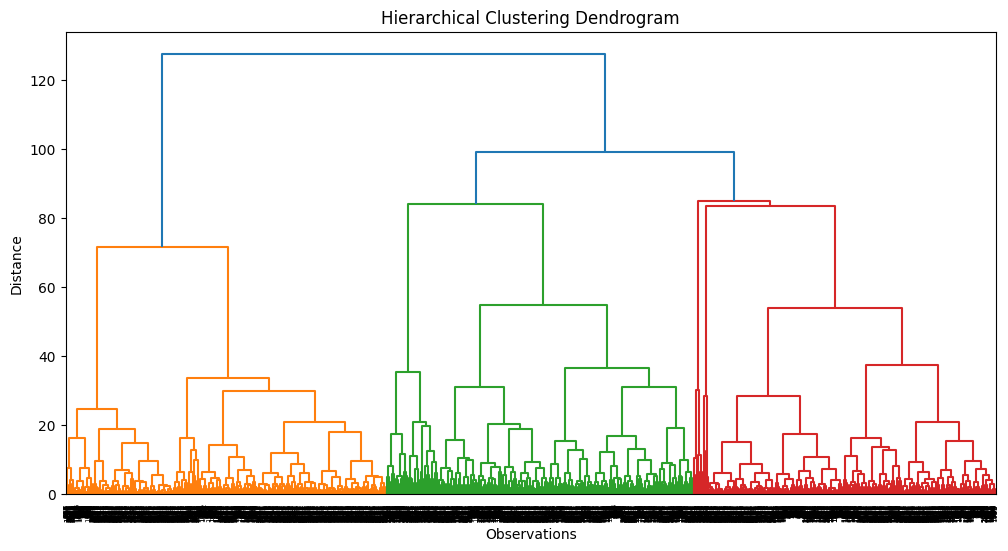

In [ ]:
# Generate linkage matrix
linked = linkage(scaled_df, method='ward')

# Plot dendrogram
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')

plt.show()

### Interpretation of the Dendrogram

The dendrogram is a tree-like diagram that visually represents the hierarchical clustering process.

Each leaf in the dendrogram represents an individual observation or data point.
As we move upward, similar observations or clusters are gradually merged together to form larger clusters.
The vertical height of each merge represents the distance or dissimilarity between the clusters being combined.

Shorter vertical lines indicate that the merged clusters are highly similar, while longer vertical lines indicate greater dissimilarity between clusters.

The dendrogram also helps determine the optimal number of clusters. By drawing a horizontal cut across the dendrogram, the number of branches intersected by the line represents the number of clusters formed at that distance threshold.

A noticeable increase in linkage distance (larger vertical gaps) indicates natural separation between clusters. Therefore, selecting the number of clusters before these large merges helps obtain meaningful clustering results.

Thus, the dendrogram provides a visual understanding of how observations are grouped together and supports the selection of an appropriate number of clusters for the Agglomerative Hierarchical Clustering model.

### Build Hierarchical Clustering Model

In [ ]:
# Create model
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

# Fit model and predict clusters
hc_labels = hc.fit_predict(scaled_df)

### Add Cluster Labels

In [ ]:
# Add cluster labels to dataframe
df_hc = df1.copy()

df_hc['Cluster'] = hc_labels

df_hc.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,1
1,19244,0,1,1,1,215,2,0,0,6968,0,1
2,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,14776,0,1,1,1,500,1,0,0,6952,0,1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0


### Evaluate using Silhouette Score

In [ ]:
# Calculate silhouette score
hc_silhouette = silhouette_score(
    scaled_df,
    hc_labels
)

print("Silhouette Score:",
      round(hc_silhouette,3))

Silhouette Score: 0.212


### Visualize Clusters using PCA

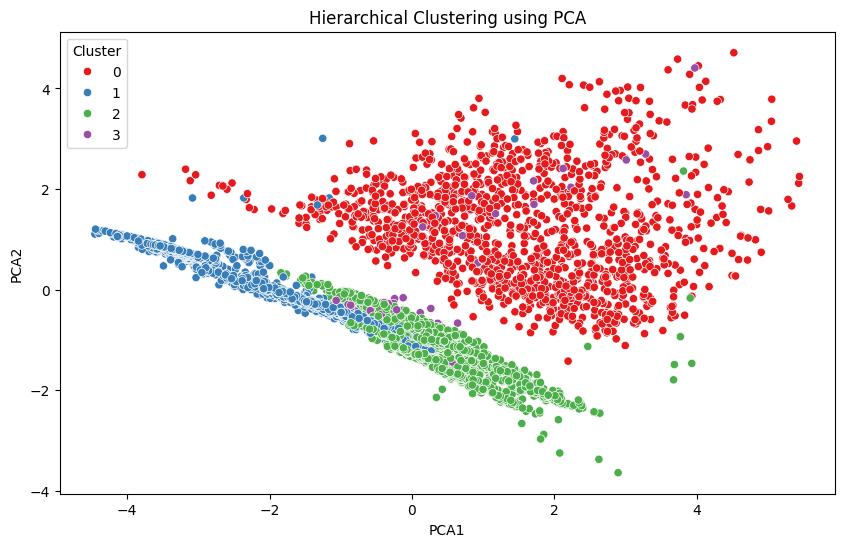

In [ ]:
# Create PCA dataframe
pca_hc = pd.DataFrame(
    pca_components,
    columns=['PCA1','PCA2']
)

# Add cluster labels
pca_hc['Cluster'] = hc_labels

# Scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_hc,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title('Hierarchical Clustering using PCA')

plt.show()

### Hierarchical Cluster Summary Statistics

In [ ]:
# Cluster-wise mean and median analysis
hc_cluster_profile = df_hc.groupby('Cluster').agg(['mean', 'median'])

display(hc_cluster_profile)

Balance           Qual_miles        cc1_miles        cc2_miles  \
                  mean   median        mean median      mean median      mean   
Cluster                                                                         
0        108802.171840  66716.0  434.619228    0.0  2.283876    1.0  1.000000   
1         29260.928986  18742.5    0.000000    0.0  1.039130    1.0  1.000000   
2         85467.940239  64385.0    0.941833    0.0  2.976892    3.0  1.000000   
3         68876.581395  37300.0   23.255814    0.0  1.139535    1.0  2.348837   

               cc3_miles         ... Bonus_trans        Flight_miles_12mo  \
        median      mean median  ...        mean median              mean   
Cluster                          ...                                        
0          1.0  1.000000    1.0  ...   15.030280   14.0       1361.391370   
1          1.0  1.000000    1.0  ...    5.101449    3.0          6.313043   
2          1.0  1.039044    1.0  ...   14.937849   14.0          6.055777   
3          2.0  1.000000    1.0  ...   17.534884   14.0        582.627907   

               Flight_trans_12        Days_since_enroll            Award?  \
        median            mean median              mean  median      mean   
Cluster                                                                     
0        563.0        4.047691    2.0       4371.643452  4419.0  0.560939   
1          0.0        0.019565    0.0       3477.478986  3259.0  0.042754   
2          0.0        0.019124    0.0       4562.225498  4610.0  0.529084   
3          0.0        2.209302    0.0       3968.930233  3726.0  0.395349   

                
        median  
Cluster         
0          1.0  
1          0.0  
2          1.0  
3          0.0  

[4 rows x 22 columns]

### Interpretation of Hierarchical Cluster Summary

The Agglomerative Hierarchical Clustering algorithm segmented customers into distinct groups based on similarities in balances, bonus miles, transactions, flight activity, and award status.

Cluster 0 represents highly active and high-value customers with higher balances, bonus miles, flight activity, and award membership.
Cluster 1 contains moderately active customers with average balances and lower engagement compared to high-value customers.
Cluster 2 consists of customers with lower activity levels but relatively higher award participation, possibly representing loyalty-program-oriented users.
Cluster 3 includes low-activity or newly enrolled customers with minimal balances, transactions, and flight activity.

Overall, the cluster summary helps identify different customer behavior patterns and supports better customer segmentation and business decision-making.

In [ ]:
## Comparison of Clustering Algorithms

comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'No_of_Clusters': [
        len(set(kmeans_labels)),
        len(set(labels)) - (1 if -1 in labels else 0),
        len(set(hc_labels))
    ],
    'Silhouette_Score': [
        round(kmeans_silhouette,3),
        round(dbscan_silhouette,3),
        round(hc_silhouette,3)
    ]
})

display(comparison_df)

,Algorithm,No_of_Clusters,Silhouette_Score
0,K-Means,4,0.239
1,DBSCAN,7,0.265
2,Hierarchical,4,0.212


## Final Conclusion

Three clustering algorithms were applied to the EastWestAirlines dataset:

K-Means Clustering

DBSCAN Clustering

Hierarchical Clustering

Each algorithm identified meaningful customer segments based on balances, bonus miles, transaction activity, flight activity, and award membership.

K-Means Clustering

K-Means segmented the customers into four major groups such as high-value frequent travelers, credit-card-based reward earners, moderately engaged users, and low-activity customers. Although the algorithm produced meaningful clusters, some overlap existed between groups because K-Means assumes spherical and equally sized clusters. The silhouette score obtained was moderate.

DBSCAN Clustering

DBSCAN generated seven distinct clusters along with a significant number of noise points (outliers). It successfully identified both dense customer groups and unusual customer behaviors. The algorithm produced more detailed and flexible segmentation, including frequent flyers, reward-oriented users, long-term loyal customers, and inactive users. DBSCAN achieved the highest silhouette score among the three methods, indicating comparatively better cluster separation and compactness.

Hierarchical Clustering

Hierarchical Clustering grouped customers into four clusters representing highly active customers, moderately active users, low-activity award participants, and newly enrolled or inactive customers. The dendrogram provided a useful visual representation of the cluster formation process. However, the silhouette score was slightly lower compared to K-Means and DBSCAN, suggesting relatively weaker cluster separation.

Overall Comparison

K-Means performed well for general customer segmentation but was sensitive to skewness and outliers.
Hierarchical Clustering provided interpretable hierarchical relationships among clusters through the dendrogram.
DBSCAN handled varying cluster densities, skewed distributions, and outliers more effectively than the other methods.

Based on the silhouette score comparison, cluster quality, and ability to identify noise points, DBSCAN appears to be the most suitable clustering algorithm for the EastWestAirlines dataset. It provided more realistic and flexible customer segmentation while effectively handling irregular cluster structures and outliers present in the data.
